# **Value at risk**

 - Paola Figueroa
 - 19 feb 2026
 

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt


# Descarga de datos
tickers = ["AAPL","MSFT","GOOGL","AMZN"]
weights = np.array([0.25,0.25,0.25,0.25])

end = dt.datetime.today()
start = end - dt.timedelta(days=365*3)

data = yf.download(tickers,start=start,end=end)["Close"]
returns = data.pct_change().dropna()

n_sim=10000
n_days=252
n_assets=len(tickers)


[*********************100%***********************]  4 of 4 completed


In [2]:
lambda_ = 0.94

ewma_var = returns.var().copy()
ewma_vol_series = []

for t in range(len(returns)):
    r_t = returns.iloc[t]
    ewma_var = lambda_ * ewma_var + (1 - lambda_) * (r_t ** 2)
    ewma_vol_series.append(np.sqrt(ewma_var))

ewma_vol_df = pd.DataFrame(ewma_vol_series, 
                           index=returns.index, 
                           columns=returns.columns)

In [3]:
corr_matrix = returns.corr()
L_corr = np.linalg.cholesky(corr_matrix)

In [4]:
# Monte Carlo con volatilidad dinámica
sigma_t=ewma_vol_df.iloc[-1].values
portfolio_paths=np.zeros((n_sim,n_days))

for s in range(n_sim):

    sigma = sigma_t.copy()
    prices_sim = np.ones(n_assets)

    for t in range(n_days):

        z = np.random.normal(size=n_assets)
        correlated = L_corr @ z

        r = sigma * correlated

        prices_sim = prices_sim * (1 + r)

        port_ret = np.dot(weights, r)

        if t == 0:
            portfolio_paths[s, t] = 1 + port_ret
        else:
            portfolio_paths[s, t] = portfolio_paths[s, t-1] * (1 + port_ret)

        sigma = np.sqrt(lambda_ * sigma**2 + (1 - lambda_) * (r**2))

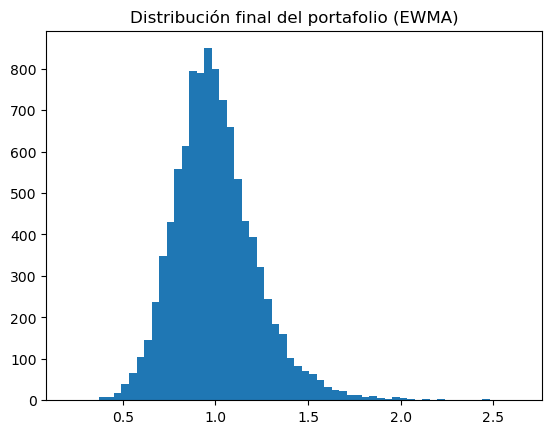

VaR 95%: 0.3282536338527796
Expected Shortfall 95%: 0.4036234817424502


In [5]:
final_values = portfolio_paths[:,-1]

plt.hist(final_values,bins=60)
plt.title("Distribución final del portafolio (EWMA)")
plt.show()

var_95 = np.percentile(final_values,5)
es_95 = final_values[final_values<=var_95].mean()

print("VaR 95%:",1-var_95)
print("Expected Shortfall 95%:",1-es_95)

# Actividad

In [6]:
#Calcular VaR (%) para tu portafolio a 15 días al 95% de confianza

#Portafolio
tickers = ["JPM", "UNH", "TSM", "JNJ"]
weights = np.array([0.35,0.30,0.20,0.15])

# Datos según los años
def get_returns(tickers, years):

    end = dt.datetime.today()
    start = end - dt.timedelta(days=365*years)

    data = yf.download(tickers, start=start, end=end, progress=False)["Close"]

    returns = data.pct_change().dropna()

    return returns


# con MGB con volatillidad constante
# 1.- Usando 1 año de data histórica
# 2.- Usando 3 años de data histórica
# 3.- Usando 5 años de data histórica
# 4.- Usando 10 años de data histórica

from scipy.stats import norm

def var_mgb_percentile(returns, weights, horizon=15, alpha=0.95):

    port_returns = returns @ weights
    simulated = []

    for i in range(10000):
        sample = np.random.choice(port_returns, size=horizon)
        total_return = np.sum(sample)
        simulated.append(total_return)

    simulated = np.array(simulated)

    # Percentil empírico
    var = -np.percentile(simulated, (1-alpha)*100)
    return var

# Con EWMA
# 1.- Usando 1 año de data histórica. Lambda =.94
# 2.- Usando 3 años de data histórica. Lambda =.94
# 3.-  Usando 5 años de data histórica. Lambda =.94
# 4,. Usando 10 años de data histórica. Lambda =.94

import numpy as np
def ewma_volatility(returns, lambda_):
    ewma_var = returns.var().values
    returns_array = returns.values
    for t in range(returns_array.shape[0]):

        ewma_var = (
            lambda_ * ewma_var
            + (1 - lambda_) * (returns_array[t] ** 2)
        )
    return np.sqrt(ewma_var)

# 5.- Usando 1 año de data histórica. Lambda =.8
# 6.-  Usando 3 años de data histórica. Lambda =.8
# 7.-Usando 5 años de data histórica. Lambda =.8
# 8.-  Usando 10 años de data histórica. Lambda =.8

def var_ewma_percentile(returns, weights, lambda_, horizon=15, alpha=0.95):
    sigma_assets = ewma_volatility(returns, lambda_)
    corr = returns.corr().values
    cov = np.outer(sigma_assets, sigma_assets) * corr
    port_sigma = np.sqrt(weights.T @ cov @ weights)
    port_returns = returns.values @ weights
    simulated = np.zeros(10000)

    for i in range(10000):

        shock = np.random.choice(port_returns, size=horizon)

        scaled = shock * (port_sigma / np.std(port_returns))

        simulated[i] = np.sum(scaled)

    # VaR empírico
    var = -np.percentile(simulated, (1-alpha)*100)

    return var



In [7]:
results = []

for y in [1,3,5,10]:

    returns = get_returns(tickers,y)

    mgb = var_mgb_percentile(returns, weights)

    ewma94 = var_ewma_percentile(returns, weights, 0.94)

    ewma08 = var_ewma_percentile(returns, weights, 0.8)

    results.append({
        "Years": y,
        "VaR MGB": mgb*100,
        "VaR EWMA λ=0.94": ewma94*100,
        "VaR EWMA λ=0.8": ewma08*100
    })

pd.DataFrame(results)



,Years,VaR MGB,VaR EWMA λ=0.94,VaR EWMA λ=0.8
0,1,5.256359,5.044125,3.901513
1,3,4.165556,4.483337,3.704639
2,5,5.159943,5.792034,4.570598
3,10,5.907342,6.539936,5.097260
